In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Exo1:
## ACP
En excluant la variable Rating, effectuer une ACP sur les variables restantes. Tracer les graphes suivants :\
• Courbe cumulative de la variance expliquée. Interpréter : a-t-on une bonne représentation ?\
• Nuage des individus projétés sur les 2 premières composantes principales, colorés par rating. Interpréter : peut-on obtenir une bonne prédiction en n’utilisant que ces deux composantes ?\
• Même nuage, colorés selon la qualité de la représentation (cos2). Interpréter : comment lier
cela à la variance expliquée ?

In [2]:
#une méthode pour l'importation des données
google_df=pd.read_csv('google_max_30.csv')
google_df

,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
0,4.1,159.0,19000000.0,4.00000,0.0,1.515283e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3.9,967.0,14000000.0,5.69897,0.0,1.515974e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4.7,87510.0,8700000.0,6.69897,0.0,1.533082e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.5,215644.0,25000000.0,7.69897,0.0,1.528416e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4.3,967.0,2800000.0,5.00000,0.0,1.529453e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7718,4.8,44.0,619000.0,3.00000,0.0,1.395533e+09,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7719,4.0,7.0,2600000.0,2.69897,0.0,1.497744e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7720,4.5,38.0,53000000.0,3.69897,0.0,1.500941e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7721,5.0,4.0,3600000.0,2.00000,0.0,1.530835e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#avec path
file_path='/Users/Yixin/Downloads/google_max_30.csv'
m=pd.read_csv(file_path,header=0)
# header=0 means that the first row contains the column names.
# header=None means pandas will not use any row as the header, 
# and the column names will be assigned default integer values

In [4]:
google_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7723 entries, 0 to 7722
Data columns (total 62 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Rating                             7723 non-null   float64
 1   Reviews                            7723 non-null   float64
 2   Size                               7723 non-null   float64
 3   Installs                           7723 non-null   float64
 4   Price                              7723 non-null   float64
 5   Timestamp                          7723 non-null   float64
 6   Category_BOOKS_AND_REFERENCE       7723 non-null   float64
 7   Category_BUSINESS                  7723 non-null   float64
 8   Category_COMMUNICATION             7723 non-null   float64
 9   Category_DATING                    7723 non-null   float64
 10  Category_EDUCATION                 7723 non-null   float64
 11  Category_FAMILY                    7723 non-null   float

In [5]:
google_df.describe()

,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
count,7723.000000,7.723000e+03,7.723000e+03,7723.000000,7723.000000,7.723000e+03,7723.000000,7723.000000,7723.000000,7723.000000,...,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000
mean,4.173935,2.948983e+05,2.297046e+07,5.059810,1.128169,1.509190e+09,0.018646,0.031853,0.027321,0.022401,...,0.013855,0.013337,0.023178,0.023566,0.022919,0.033795,0.081963,0.020588,0.014891,0.192930
std,0.544638,1.863933e+06,2.344963e+07,1.608296,17.408036,3.595212e+07,0.135279,0.175620,0.163028,0.147992,...,0.116895,0.114720,0.150477,0.151702,0.149654,0.180713,0.274326,0.142009,0.121123,0.394624
min,1.000000,1.000000e+00,8.500000e+03,0.000000,0.000000,1.274400e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.075000e+02,5.300000e+06,4.000000,0.000000,1.501286e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.300000,2.332000e+03,1.400000e+07,5.000000,0.000000,1.526342e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000,3.905300e+04,3.300000e+07,6.000000,0.000000,1.531786e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,4.489389e+07,1.000000e+08,9.000000,400.000000,1.533686e+09,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
data=google_df.iloc[:,1:] #exclure Rating
rating=google_df.Rating.values

In [8]:
#data-=data.mean()centrer
#data/=data.std()réduire

In [36]:
from sklearn.preprocessing import StandardScaler
data=StandardScaler().fit_transform(data)

In [38]:
acp=PCA()
acp.fit(data)

PCA()

In [39]:
plt.rcParams['figure.figsize'] = (15, 7)  # Taille par défaut de la figure
plt.rcParams['axes.titlesize']=18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['legend.fontsize']=10
plt.rcParams['legend.title_fontsize'] = 12


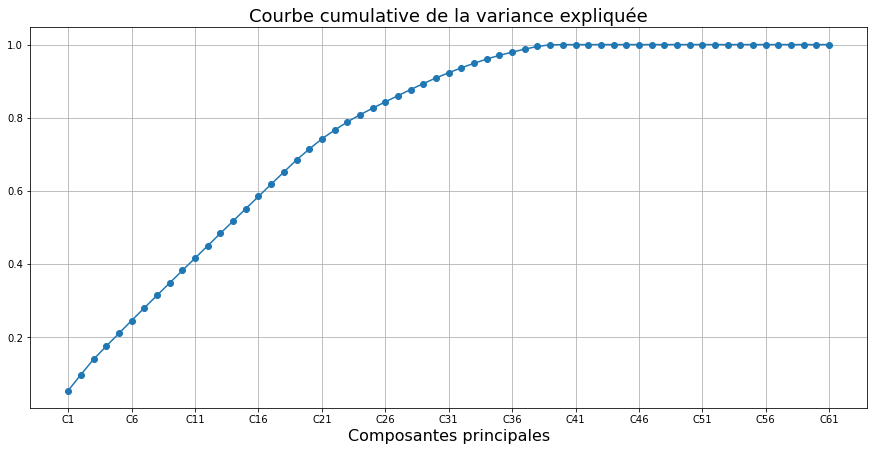

In [72]:
plt.plot(np.cumsum(acp.explained_variance_ratio_), '-o')
x=np.arange(0,len(acp.explained_variance_ratio_),5)
plt.grid()
plt.title('Courbe cumulative de la variance expliquée')
plt.xlabel('Composantes principales')
C=[f'C{5*i+1}' for i in range(len(x))] 
plt.xticks(x,C)
plt.show()


<Figure size 1440x720 with 0 Axes>

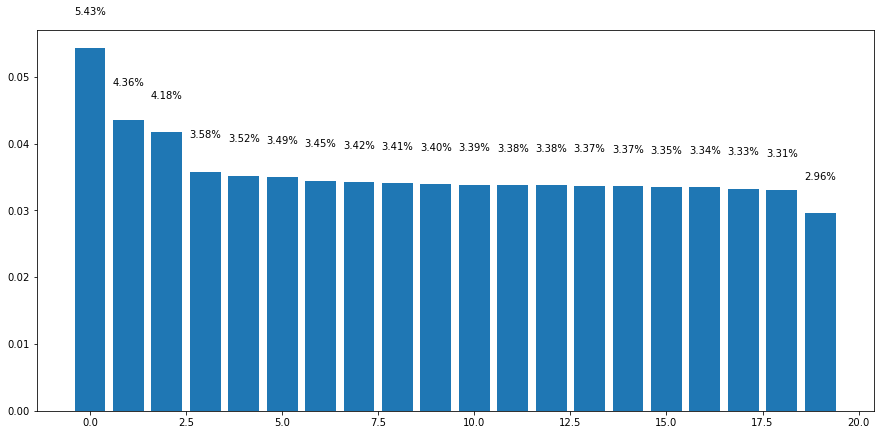

<Figure size 1440x720 with 0 Axes>

In [41]:
#Pour vérifier c'est une bonne interprétation.
plt.bar(range(20), acp.explained_variance_ratio_[:20])
for i, var in enumerate(acp.explained_variance_ratio_[:20]):
    plt.text(i, var + 0.005,f'{var:.2%}', ha='center',size='10')
plt.figure(figsize=(20, 10))

On voit que les deux première CP décrivent moins de 10% de la variance, cela pourrait signifier que la structure des données est complexe et l'ACP ici ne capture pas suffisamment d'information.

In [73]:
len(acp.explained_variance_ratio_)

61

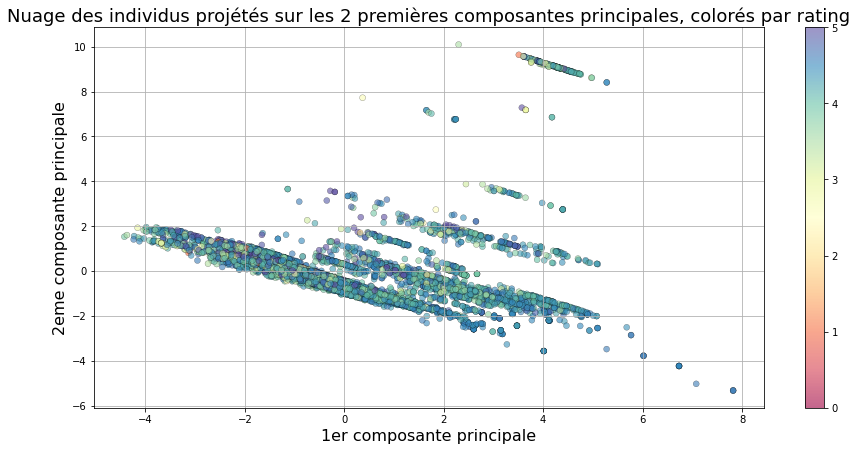

In [74]:
cp=acp.transform(data)

plt.title('Nuage des individus projétés sur les 2 premières composantes principales, colorés par rating')
plt.xlabel('1er composante principale')
plt.ylabel('2eme composante principale')
r=plt.scatter(cp[:, 0], cp[:, 1], c=rating, cmap='Spectral', vmin=0, vmax=5, edgecolor='k', linewidth=0.3, alpha=0.6)
plt.grid()
plt.colorbar()

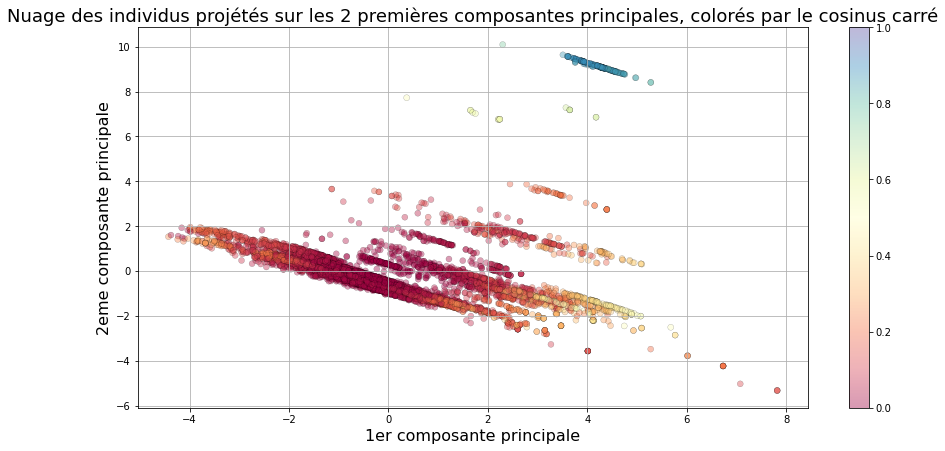

In [76]:
#pour cos^2
numerateur = np.sum(cp[:, :2] ** 2, axis=1)
normes2 = np.sum(cp ** 2, axis=1)
cosines2 = numerateur / normes2

plt.title('Nuage des individus projétés sur les 2 premières composantes principales, colorés par le cosinus carré')
plt.xlabel('1er composante principale')
plt.ylabel('2eme composante principale')
r=plt.scatter(cp[:, 0], cp[:, 1], c=cosines2, cmap='Spectral', vmin=0, vmax=1, edgecolor='k', linewidth=0.3, alpha=0.4)
plt.grid()
plt.colorbar()

On trouve que la plupart des points sont colorés en rouge, c'est à dire que la cosines carré de ces points sont proches de 0(si cela est proche de 1, c'est une bonne représentation), donc c'est pas une bonne interprétation

# Exo2
## AFD
• Créer une variable target en divisant les applications ayant rating < 4.1, celles ayant entre 4.1 et 4.4, et celles ayant > 4.4. Appliquer une AFD linéaire aux mêmes données, en utilisant target come variable de référence. Combien d’axes factoriels obtient-on ? Pourquoi ?\
• Tracer une nuage colorée selon target. A-t-on une bonne séparation des trois classes ?\
• Calculer l’accuracy de cette méthode de classification et la matrice de confusion. Est-ce
satisfaisant ?

In [45]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [46]:
lda=LinearDiscriminantAnalysis()

In [63]:
google_df.loc[google_df.Rating<4.1,'target']=1
google_df.loc[(google_df.Rating>=4.1) & (google_df.Rating<=4.4),'target']=2
google_df.loc[google_df.Rating>4.1,'target']=3


In [65]:
data2=google_df.iloc[:,1:-1]
data2=StandardScaler().fit_transform(data2)

In [79]:
fd=lda.fit_transform(data2,target)
fd.shape

(7723, 2)

On a deux axes factoriels parce que on a trois classes ici.

(-5.0, 5.0)

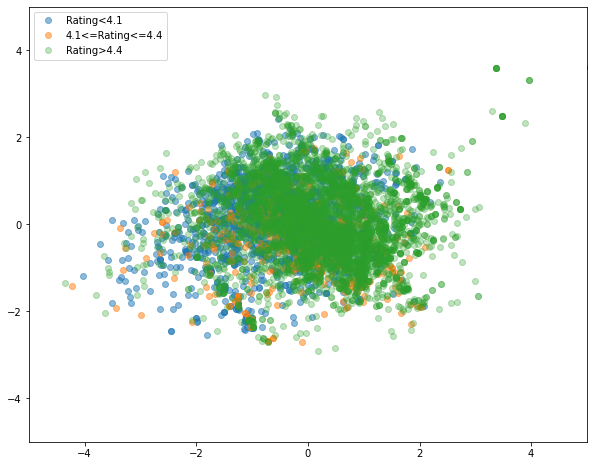

In [68]:
plt.figure(figsize=(10,8))
plt.plot(fd[target == 1, 0], fd[target == 1, 1], 'o', label='Rating<4.1', alpha=0.5)
plt.plot(fd[target == 2, 0], fd[target == 2, 1], 'o', label='4.1<=Rating<=4.4', alpha=0.5)
plt.plot(fd[target == 3, 0], fd[target == 3, 1], 'o', label='Rating>4.4',alpha=0.3) 
plt.legend()
plt.xlim(-5,5)
plt.ylim(-5,5)

Sur le graphe ci-dessus, on se voit que les trois classes ne peuvent pas bien separée.

In [69]:
preds = lda.predict(data2)
accuracy = (preds == target).mean()
print(f'Accuracy : {accuracy:.3%}')


Accuracy : 63.395%


In [70]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay 
cm = confusion_matrix(target, preds)
acc = accuracy_score(target, preds)
print(cm,acc)

[[ 395    0 1885]
 [  64    3  526]
 [ 350    2 4498]] 0.6339505373559498


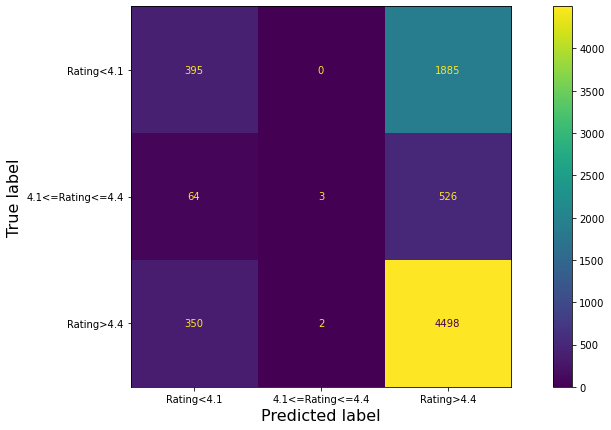

In [59]:
ConfusionMatrixDisplay(cm, display_labels=['Rating<4.1', '4.1<=Rating<=4.4','Rating>4.4']).plot()

PAS SATISFAIT

## SVM

• Entraîner une SVM linéaire (LinearSVR) pour prédire Rating, en utilisant toutes les données\
• Calculer la corrélation entre prédiction et vraie valeur, et tracer le scatterplot qui les compare.\
• Répéter l’entraînement en utilisant, cette fois, une SVM non-linéaire (par exemple, noyau
rbf) sur toutes les données. Est-ce meilleur ?


In [31]:
from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVR
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(data, rating, test_size=0.3, random_state=42)
#sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)[source]

linear_svr = LinearSVR(max_iter=1000000,dual=True)
linear_svr.fit(data, rating)


LinearSVR(max_iter=1000000)

Corrélation (LinearSVR): 0.222


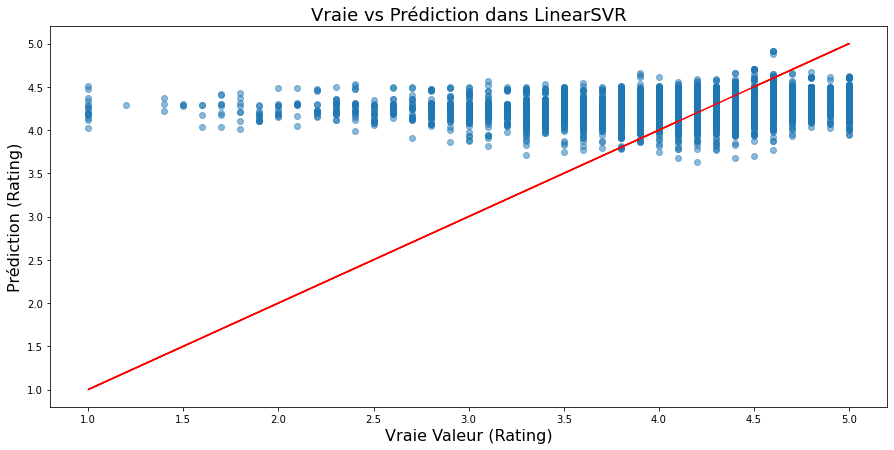

In [81]:
predictions_linear = linear_svr.predict(data)

# Calculer la corrélation entre prédiction et vraie valeur
correlation_linear = np.corrcoef(rating, predictions_linear)[0, 1]
print(f"Corrélation (LinearSVR): {correlation_linear:.3f}")

# Tracer le scatterplot
plt.scatter(rating, predictions_linear, alpha=0.5)
plt.plot(rating,rating,'r')
plt.title('Vraie vs Prédiction dans LinearSVR')
plt.xlabel('Vraie Valeur (Rating)')
plt.ylabel('Prédiction (Rating)')
plt.show()


Corrélation (SVR): 0.343


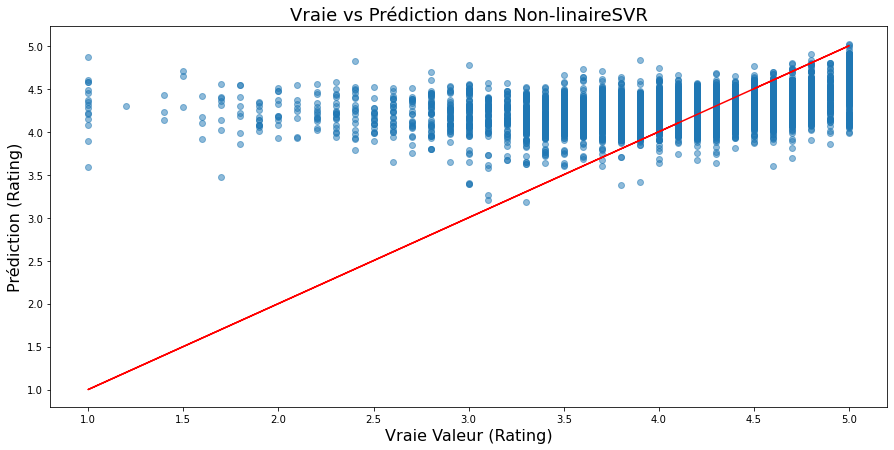

In [83]:
from sklearn.svm import SVR
svm_reg= SVR(kernel='rbf')
svm_reg.fit(data, rating)
predictions = svm_reg.predict(data)
plt.scatter(rating, predictions, alpha=0.5)
plt.plot(rating,rating,'r')
plt.title('Vraie vs Prédiction dans Non-linaireSVR')
plt.xlabel('Vraie Valeur (Rating)')
plt.ylabel('Prédiction (Rating)')
correlation = np.corrcoef(rating, predictions)[0, 1]
print(f"Corrélation (SVR): {correlation:.3f}")

## Réseaux de neurones
• Entraîner un réseau de neurones (MLPRegressor) avec les paramètres standards. Peut-on dire si c’est mieux des méthodes ci-dessus ?\
• Séparer le jeu de données en 80% d’entraînement et 20% de test. Répéter l’entraînement de AFD, SVM (linéaire et non) et les deux réseaux de neurones, en n’entraînant que sur le premier 80% et évaluant sur le reste. Comment changent les résultats ?

Corrélation (MLPRegressor): 0.450


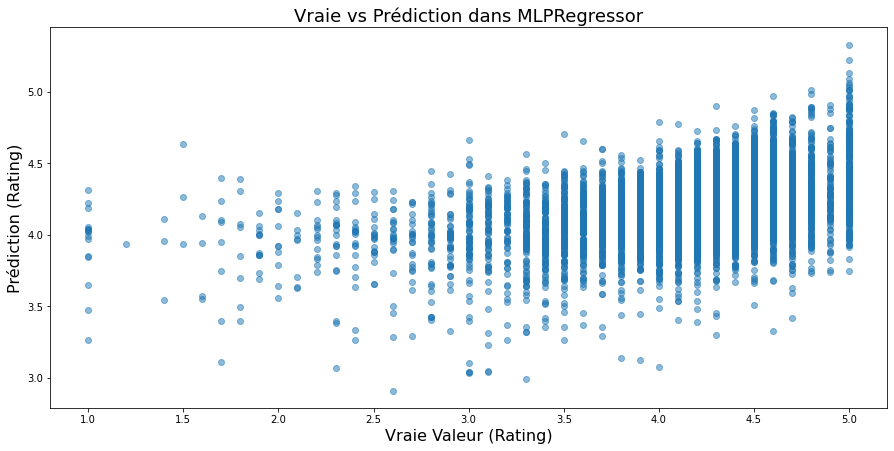

In [84]:
from sklearn.neural_network import MLPRegressor

mlp_regressor = MLPRegressor(random_state=42)
mlp_regressor.fit(data, rating)

predictions_mlp = mlp_regressor.predict(data)
plt.title('Vraie vs Prédiction dans MLPRegressor')
plt.xlabel('Vraie Valeur (Rating)')
plt.ylabel('Prédiction (Rating)')

plt.scatter(rating,predictions_mlp,alpha=0.5)
correlation = np.corrcoef(rating, predictions_mlp)[0, 1]
print(f"Corrélation (MLPRegressor): {correlation:.3f}")

In [91]:
X_train, X_test, y_train, y_test = train_test_split(data, rating, test_size=0.2, random_state=42)

Corrélation (MLPRegressor): 0.326


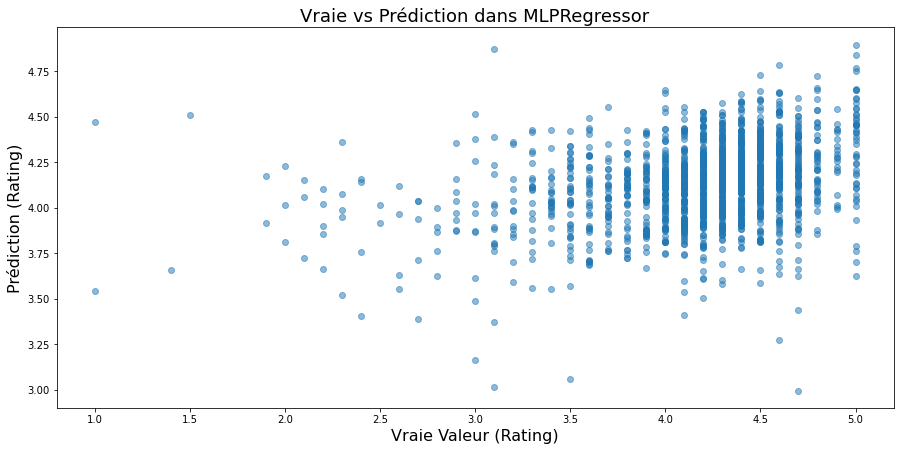

In [93]:
from sklearn.neural_network import MLPRegressor

mlp_regressor = MLPRegressor(random_state=42)
mlp_regressor.fit(X_train, y_train)

predictions_mlp = mlp_regressor.predict(X_test)
plt.title('Vraie vs Prédiction dans MLPRegressor')
plt.xlabel('Vraie Valeur (Rating)')
plt.ylabel('Prédiction (Rating)')

plt.scatter(y_test,predictions_mlp,alpha=0.5)
correlation = np.corrcoef(y_test, predictions_mlp)[0, 1]
print(f"Corrélation (MLPRegressor): {correlation:.3f}")

Corrélation (SVR): 0.261


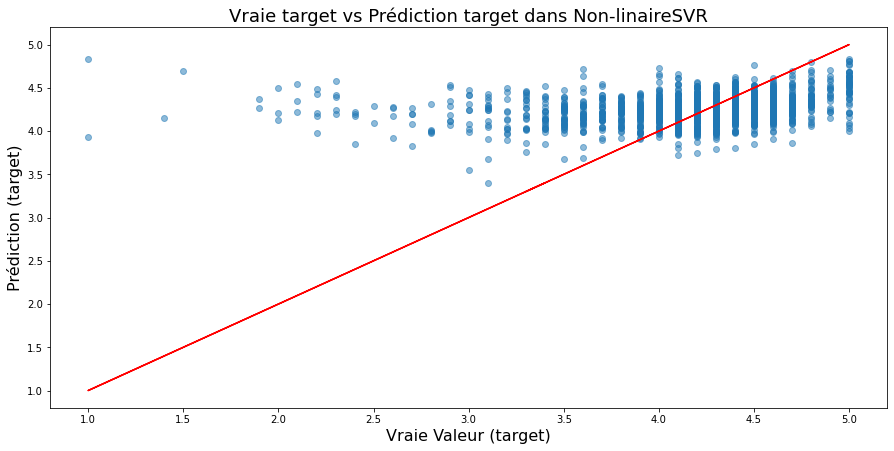

In [86]:
from sklearn.svm import SVR
svm_reg= SVR(kernel='rbf')
svm_reg.fit(X_train, y_train)
predictions = svm_reg.predict(X_test)
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot(y_test,y_test,'r')
plt.title('Vraie target vs Prédiction target dans Non-linaireSVR')
plt.xlabel('Vraie Valeur (target)')
plt.ylabel('Prédiction (target)')
correlation = np.corrcoef(y_test, predictions)[0, 1]
print(f"Corrélation (SVR): {correlation:.3f}")

Corrélation (LinearSVR): 0.208


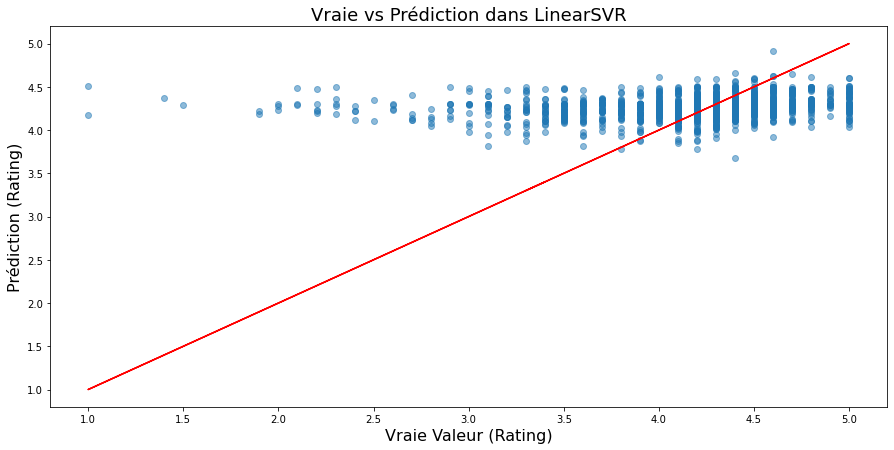

In [87]:
predictions_linear = linear_svr.predict(X_test)

# Calculer la corrélation entre prédiction et vraie valeur
correlation_linear = np.corrcoef(y_test, predictions_linear)[0, 1]
print(f"Corrélation (LinearSVR): {correlation_linear:.3f}")

# Tracer le scatterplot
plt.scatter(y_test, predictions_linear, alpha=0.5)
plt.plot(y_test,y_test,'r')
plt.title('Vraie vs Prédiction dans LinearSVR')
plt.xlabel('Vraie Valeur (Rating)')
plt.ylabel('Prédiction (Rating)')
plt.show()

Accuracy : 63.395%


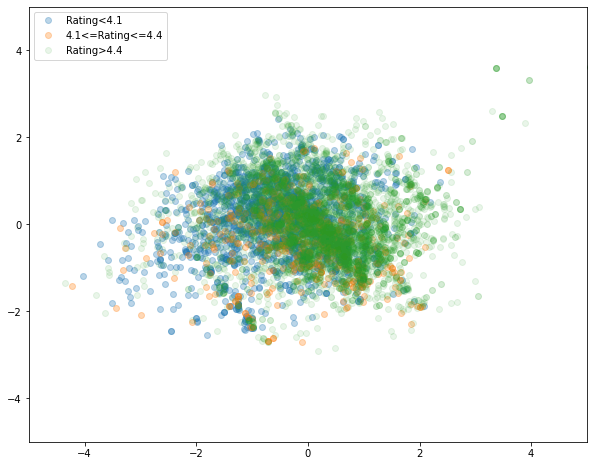

In [94]:
X_train, X_test, y_train, y_test = train_test_split(data2, target, test_size=0.2, random_state=42)

fd2=lda.fit_transform(X_train, y_train)

predictions_afd = lda.predict(X_test)
plt.figure(figsize=(10,8))
plt.plot(fd[target == 1, 0], fd[target == 1, 1], 'o', label='Rating<4.1', alpha=0.3)
plt.plot(fd[target == 2, 0], fd[target == 2, 1], 'o', label='4.1<=Rating<=4.4', alpha=0.3)
plt.plot(fd[target == 3, 0], fd[target == 3, 1], 'o', label='Rating>4.4',alpha=0.1) 
plt.legend()
plt.xlim(-5,5)
plt.ylim(-5,5)
accuracy = (preds == target).mean()
print(f'Accuracy : {accuracy:.3%}')
